# Introducción al clustering con K-Means

En este cuaderno vamos a introducir el aprendizaje no supervisado a partir de un ejemplo visual y controlado.

Hasta ahora, en muchos problemas de Machine Learning trabajamos con aprendizaje supervisado. En ese enfoque, el dataset incluye una variable objetivo conocida, y el modelo aprende a predecirla. Por ejemplo, podríamos entrenar un modelo para clasificar correos, predecir si una persona compra un producto o estimar la especie de un animal a partir de sus características.

En este cuaderno haremos algo diferente.

Vamos a trabajar con datos sintéticos, es decir, datos generados artificialmente para poder observar con claridad cómo funciona un algoritmo de clustering. El objetivo será entender cómo un modelo puede encontrar grupos en los datos sin recibir etiquetas previas.

La pregunta que guiará el trabajo será:

> ¿Cómo puede un algoritmo encontrar grupos en los datos si no le decimos de antemano a qué grupo pertenece cada punto?

Para responderla, utilizaremos **K-Means**, uno de los algoritmos de clustering más conocidos.

A lo largo del cuaderno vamos a trabajar los siguientes temas:

- qué es el aprendizaje no supervisado;
- qué es el clustering;
- cómo funciona K-Means;
- por qué es importante escalar los datos;
- cómo elegir la cantidad de clusters cuando no la conocemos;
- cómo evaluar un clustering sin etiquetas;
- cómo interpretar los clusters encontrados;
- cuáles son algunas limitaciones de K-Means.

La idea principal no será solamente ejecutar un algoritmo, sino entender qué decisiones tomamos, qué significan los resultados y por qué K-Means funciona muy bien en algunos casos, pero puede fallar en otros.

## 1. Aprendizaje supervisado y aprendizaje no supervisado

En el aprendizaje supervisado, los datos incluyen una respuesta conocida.

Por ejemplo, si queremos entrenar un modelo de clasificación, necesitamos una variable objetivo que indique la clase correcta de cada registro. El modelo aprende a partir de ejemplos ya etiquetados.

En cambio, en el **aprendizaje no supervisado** no contamos con una variable objetivo. El modelo no recibe respuestas correctas. Su tarea consiste en buscar patrones, relaciones o estructuras ocultas dentro de los datos.

Una de las técnicas más importantes dentro del aprendizaje no supervisado es el **clustering**, también llamado agrupamiento.

El clustering busca formar grupos de observaciones similares entre sí. La idea es que los elementos dentro de un mismo grupo sean parecidos, mientras que los elementos de grupos distintos sean más diferentes.

Esto puede ser útil, por ejemplo, para:

- segmentar clientes según hábitos de consumo;
- agrupar usuarios según comportamiento;
- detectar perfiles similares dentro de una población;
- explorar datos cuando todavía no conocemos sus categorías;
- descubrir estructuras ocultas en un conjunto de datos.

En este cuaderno trabajaremos con datos sintéticos para poder ver estas ideas de manera clara y visual.

## 2. Importamos las librerías necesarias

Antes de comenzar, importamos las librerías que vamos a utilizar.

Usaremos `numpy` y `pandas` para trabajar con datos, `matplotlib` y `seaborn` para construir gráficos, y herramientas de `scikit-learn` para generar datos sintéticos, escalar variables, entrenar K-Means y evaluar los resultados.

En este cuaderno no usaremos `Pipeline`, porque queremos observar cada paso de manera explícita.

In [5]:
# ---------------------------------------------------------
# Librerías para manejo de datos
# ---------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Librerías para visualización
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Herramientas de Scikit-learn
# ---------------------------------------------------------
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ---------------------------------------------------------
# Configuración general de visualización
# ---------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Generamos un dataset sintético

Para comenzar, vamos a crear un conjunto de datos artificial.

Esto nos permite trabajar en un escenario controlado: sabemos que los datos fueron generados a partir de varios grupos, pero vamos a simular que no conocemos esas etiquetas.

Usaremos la función `make_blobs` de `scikit-learn`, que permite generar puntos distribuidos alrededor de ciertos centros.

En este primer ejemplo vamos a generar:

- 400 puntos;
- 4 grupos reales;
- 2 variables numéricas;
- grupos relativamente separados.

Aunque `make_blobs` también devuelve una etiqueta real para cada punto, no la usaremos para entrenar K-Means. La reservaremos solo para interpretar los resultados más adelante.

In [8]:
# ---------------------------------------------------------
# Generamos datos sintéticos con grupos bien definidos
# ---------------------------------------------------------

X, etiquetas_reales = make_blobs(
    n_samples=400,
    centers=4,
    n_features=2,
    cluster_std=0.80,
    random_state=42
)

# ---------------------------------------------------------
# Convertimos los datos a un DataFrame para trabajar mejor
# ---------------------------------------------------------

df = pd.DataFrame(
    X,
    columns=["variable_1", "variable_2"]
)

# Guardamos las etiquetas reales solo como referencia posterior
df["grupo_real"] = etiquetas_reales

# ---------------------------------------------------------
# Mostramos las primeras filas
# ---------------------------------------------------------

display(df.head())

print("Dimensiones del dataset:")
print(df.shape)

,variable_1,variable_2,grupo_real
0,-10.105953,9.060769,3
1,-5.102745,9.827970,0
2,-9.081613,7.053527,3
3,5.605247,1.827583,1
4,5.205060,3.097380,1


Dimensiones del dataset:
(400, 3)


## 4. Observamos los datos sin etiquetas

En un problema real de clustering, normalmente no conocemos a qué grupo pertenece cada observación.

Por eso, aunque nuestro dataset sintético incluye una columna llamada `grupo_real`, por ahora no la vamos a usar.

Primero vamos a observar solamente las dos variables numéricas:

- `variable_1`
- `variable_2`

Cada punto del gráfico representa una observación del dataset.

La pregunta inicial será:

> ¿Parece haber grupos naturales en estos datos?

Esta observación visual no reemplaza al algoritmo, pero nos ayuda a desarrollar intuición sobre la estructura del dataset.

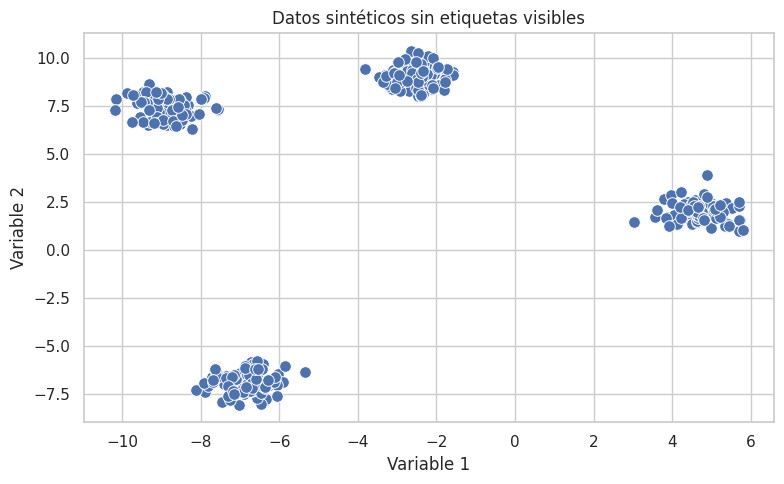

In [7]:
# ---------------------------------------------------------
# Gráfico de los datos sin usar las etiquetas reales
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="variable_1",
    y="variable_2",
    s=70
)

plt.title("Datos sintéticos sin etiquetas visibles")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.tight_layout()
plt.show()

## 5. ¿Qué intentará hacer K-Means?

Al observar el gráfico anterior, parece razonable pensar que los puntos podrían organizarse en grupos.

K-Means intentará hacer justamente eso: dividir los datos en `k` clusters, de manera que los puntos dentro de cada cluster queden lo más cerca posible entre sí.

La idea general del algoritmo es la siguiente:

1. Elegir una cantidad de clusters `k`.
2. Ubicar inicialmente `k` centroides.
3. Asignar cada punto al centroide más cercano.
4. Recalcular cada centroide como el promedio de los puntos que quedaron en su grupo.
5. Repetir el proceso hasta que las asignaciones se estabilicen.

Un **centroide** es el punto central de un cluster. No necesariamente coincide con una observación real del dataset; representa una posición promedio.

En este primer ejemplo, como visualmente parecen existir cuatro grupos, vamos a comenzar probando K-Means con `k = 4`.

## 6. Separamos las variables que usará el algoritmo

Antes de entrenar K-Means, vamos a separar las variables numéricas que usará el algoritmo.

En este caso, usaremos solamente:

- `variable_1`
- `variable_2`

No usaremos `grupo_real` para entrenar. Esa columna representa la etiqueta con la que fueron generados los datos, pero en un problema real de clustering no tendríamos esa información.

La conservaremos únicamente para comparar los resultados más adelante.

In [9]:
# ---------------------------------------------------------
# Seleccionamos las variables que usará K-Means
# ---------------------------------------------------------

X = df[["variable_1", "variable_2"]]

# ---------------------------------------------------------
# Revisamos las primeras filas
# ---------------------------------------------------------

display(X.head())

print("Dimensiones de X:")
print(X.shape)

,variable_1,variable_2
0,-10.105953,9.060769
1,-5.102745,9.827970
2,-9.081613,7.053527
3,5.605247,1.827583
4,5.205060,3.097380


Dimensiones de X:
(400, 2)


## 7. Revisamos las escalas de las variables

K-Means se basa en distancias. Por eso, la escala de las variables es muy importante.

Si una variable tiene valores mucho más grandes que otra, puede dominar el cálculo de distancia y afectar la formación de los clusters.

En este dataset sintético tenemos solo dos variables, `variable_1` y `variable_2`. Vamos a revisar sus estadísticas descriptivas y sus distribuciones para decidir si necesitamos escalarlas.

Aunque las escalas parezcan similares, vamos a aplicar estandarización de todos modos para mostrar una práctica habitual antes de usar K-Means.

,count,mean,std,min,25%,50%,75%,max
variable_1,400.0,-3.424523,5.331237,-11.508246,-8.015406,-4.624134,-0.123649,6.931391
variable_2,400.0,2.862982,6.333156,-9.159012,-1.127579,5.450661,8.272653,11.707254


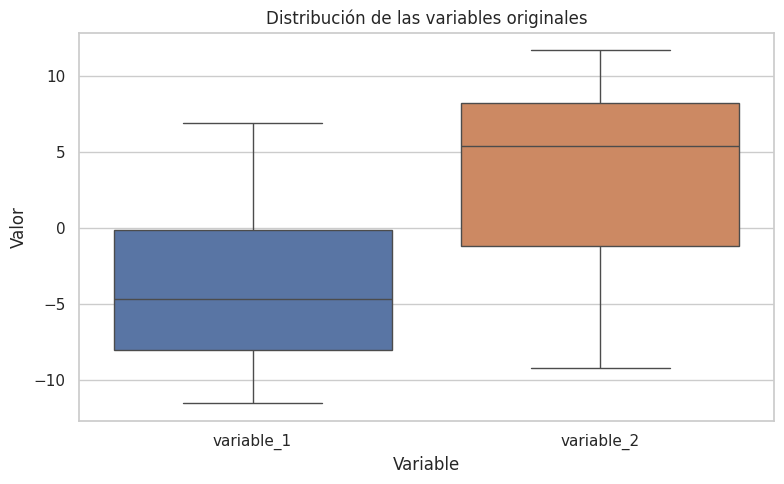

In [10]:
# ---------------------------------------------------------
# Estadísticas descriptivas de las variables
# ---------------------------------------------------------

resumen_variables = X.describe().T

display(resumen_variables)

# ---------------------------------------------------------
# Gráfico de caja para comparar escalas
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(data=X)

plt.title("Distribución de las variables originales")
plt.xlabel("Variable")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

## 8. Estandarizamos los datos

Aunque las variables de este dataset sintético tienen escalas relativamente similares, vamos a aplicar estandarización.

Esto nos permite trabajar de forma consistente y reforzar una idea importante:

> K-Means calcula distancias, por lo tanto la escala de las variables puede afectar el resultado.

Usaremos `StandardScaler`, que transforma cada variable para que tenga media cercana a 0 y desvío estándar cercano a 1.

A partir de este punto, entrenaremos K-Means usando los datos escalados.

In [11]:
# ---------------------------------------------------------
# Creamos el escalador
# ---------------------------------------------------------

escalador = StandardScaler()

# ---------------------------------------------------------
# Ajustamos el escalador y transformamos los datos
# ---------------------------------------------------------

X_escalado = escalador.fit_transform(X)

# ---------------------------------------------------------
# Convertimos el resultado a DataFrame para visualizarlo mejor
# ---------------------------------------------------------

X_escalado_df = pd.DataFrame(
    X_escalado,
    columns=["variable_1", "variable_2"]
)

# ---------------------------------------------------------
# Mostramos las primeras filas escaladas
# ---------------------------------------------------------

display(X_escalado_df.head())

,variable_1,variable_2
0,-1.254830,0.979851
1,-0.315185,1.101143
2,-1.062450,0.662512
3,1.695869,-0.163693
4,1.620710,0.037058


## 9. Verificamos el resultado de la estandarización

Después de escalar los datos, revisamos nuevamente las estadísticas descriptivas y las distribuciones.

Si la estandarización se aplicó correctamente, las variables deberían tener:

- media cercana a 0;
- desvío estándar cercano a 1.

Esto no significa que los puntos hayan perdido su estructura. Los grupos siguen estando presentes, pero ahora las variables están expresadas en una escala común.

,count,mean,std,min,25%,50%,75%,max
variable_1,400.0,5.995204e-17,1.001252,-1.518193,-0.862207,-0.225297,0.619933,1.944930
variable_2,400.0,2.886580e-17,1.001252,-1.900640,-0.630895,0.409104,0.855252,1.398252


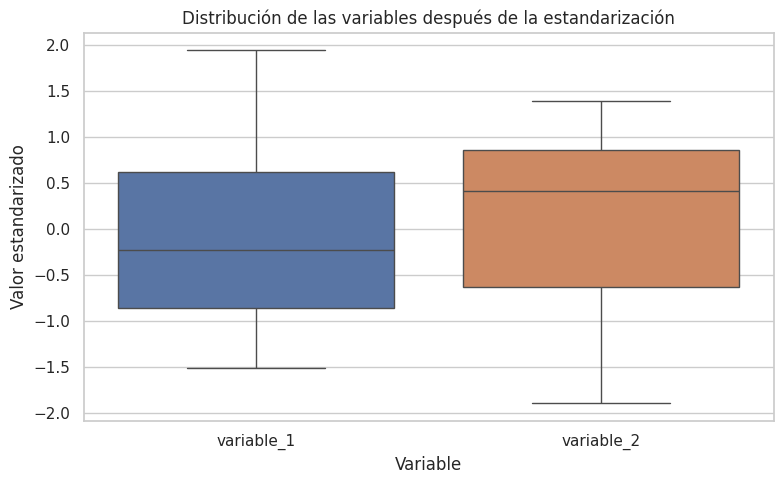

In [12]:
# ---------------------------------------------------------
# Estadísticas descriptivas de los datos escalados
# ---------------------------------------------------------

resumen_escalado = X_escalado_df.describe().T

display(resumen_escalado)

# ---------------------------------------------------------
# Gráfico de caja de las variables escaladas
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(data=X_escalado_df)

plt.title("Distribución de las variables después de la estandarización")
plt.xlabel("Variable")
plt.ylabel("Valor estandarizado")
plt.tight_layout()
plt.show()

## 10. Entrenamos K-Means con k = 4

Ahora vamos a entrenar nuestro primer modelo K-Means.

Como visualmente observamos cuatro grupos bastante claros, comenzaremos usando `k = 4`.

Esto significa que le pediremos al algoritmo que divida los datos en cuatro clusters.

Es importante recordar que K-Means no conoce las etiquetas reales de los datos. Solo recibe las coordenadas escaladas de cada punto y busca organizar los datos en grupos compactos.

Después del entrenamiento, el modelo nos permitirá obtener:

- la etiqueta de cluster asignada a cada punto;
- la posición de los centroides;
- la inercia del modelo.

In [13]:
# ---------------------------------------------------------
# Creamos el modelo K-Means con k = 4
# ---------------------------------------------------------

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# ---------------------------------------------------------
# Entrenamos el modelo con los datos escalados
# ---------------------------------------------------------

kmeans_4.fit(X_escalado_df)

# ---------------------------------------------------------
# Obtenemos las etiquetas de cluster asignadas
# ---------------------------------------------------------

clusters_k4 = kmeans_4.labels_

print("Modelo K-Means entrenado correctamente.")
print("Primeras etiquetas de cluster asignadas:")
print(clusters_k4[:20])

Modelo K-Means entrenado correctamente.
Primeras etiquetas de cluster asignadas:
[1 3 1 0 0 3 3 1 3 0 1 0 1 0 2 2 2 3 0 2]


## 11. Agregamos los clusters al dataset

El modelo ya asignó una etiqueta de cluster a cada punto.

Estas etiquetas aparecen como números: `0`, `1`, `2` y `3`.

Es importante entender que esos números no tienen un significado propio. El cluster `0` no es “mejor”, “menor” ni “anterior” al cluster `1`. Son simplemente nombres que el algoritmo utiliza para identificar los grupos encontrados.

Vamos a agregar estas etiquetas al DataFrame para poder analizarlas y graficarlas.

In [14]:
# ---------------------------------------------------------
# Creamos una copia del DataFrame original
# ---------------------------------------------------------

df_k4 = df.copy()

# ---------------------------------------------------------
# Agregamos la etiqueta de cluster asignada por K-Means
# ---------------------------------------------------------

df_k4["cluster_k4"] = clusters_k4

# ---------------------------------------------------------
# Mostramos las primeras filas
# ---------------------------------------------------------

display(df_k4.head())

,variable_1,variable_2,grupo_real,cluster_k4
0,-10.105953,9.060769,3,1
1,-5.102745,9.827970,0,3
2,-9.081613,7.053527,3,1
3,5.605247,1.827583,1,0
4,5.205060,3.097380,1,0


## 12. Analizamos cuántos puntos quedaron en cada cluster

Una primera forma de analizar el resultado de K-Means es contar cuántas observaciones quedaron asignadas a cada cluster.

En este dataset sintético generamos grupos del mismo tamaño, pero el algoritmo no sabe eso. Solo agrupa los puntos según las distancias entre ellos.

Si K-Means encontró correctamente los grupos, deberíamos observar una cantidad parecida de puntos en cada cluster.

Vamos a mostrar esta información en una tabla y también en un gráfico de barras.

,count
cluster_k4,
0,100
1,100
2,100
3,100


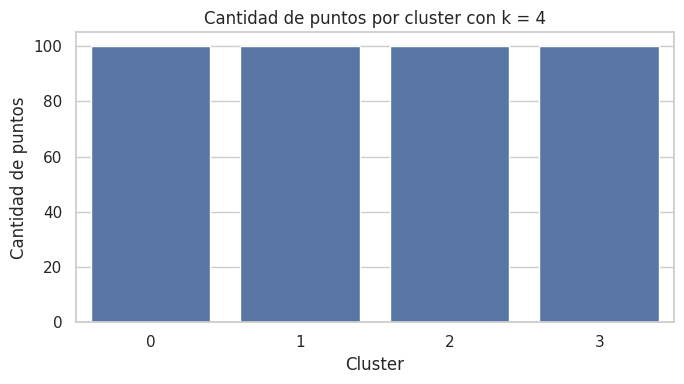

In [15]:
# ---------------------------------------------------------
# Conteo de puntos por cluster
# ---------------------------------------------------------

conteo_clusters_k4 = df_k4["cluster_k4"].value_counts().sort_index()

display(conteo_clusters_k4)

# ---------------------------------------------------------
# Gráfico de barras
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.barplot(
    x=conteo_clusters_k4.index,
    y=conteo_clusters_k4.values
)

plt.title("Cantidad de puntos por cluster con k = 4")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de puntos")
plt.tight_layout()
plt.show()

## 13. Visualizamos los clusters encontrados

Ahora vamos a graficar los puntos coloreados según el cluster asignado por K-Means.

Esto nos permitirá ver si el algoritmo logró separar los grupos que observábamos visualmente al comienzo.

Además, vamos a marcar los centroides. Recordemos que un centroide representa el centro promedio de cada cluster. No necesariamente coincide con un punto real del dataset, sino que resume la posición central del grupo.

,variable_1,variable_2,cluster_k4
0,4.746031,2.010220,0
1,-8.928302,7.381376,1
2,-6.883829,-6.982945,2
3,-2.631992,9.043277,3


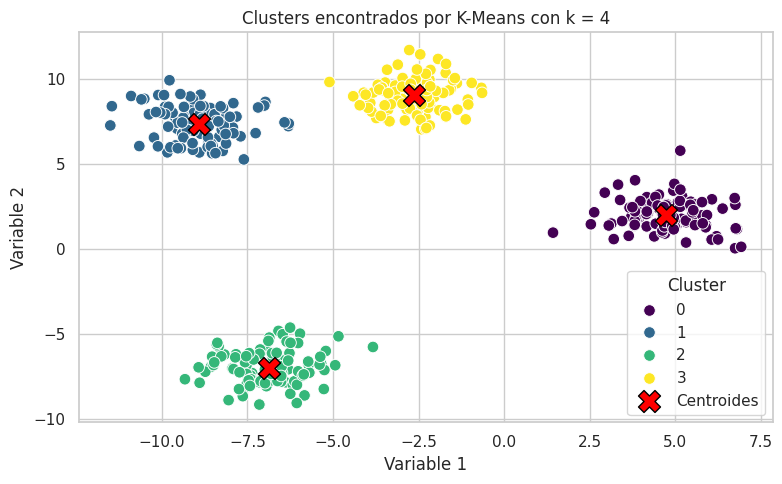

In [16]:
# ---------------------------------------------------------
# Obtenemos los centroides en escala estandarizada
# ---------------------------------------------------------

centroides_escalados = kmeans_4.cluster_centers_

# ---------------------------------------------------------
# Convertimos los centroides a la escala original
# ---------------------------------------------------------
# Esto permite graficarlos sobre las variables originales.

centroides_originales = escalador.inverse_transform(centroides_escalados)

centroides_df = pd.DataFrame(
    centroides_originales,
    columns=["variable_1", "variable_2"]
)

centroides_df["cluster_k4"] = range(4)

display(centroides_df)

# ---------------------------------------------------------
# Gráfico de clusters y centroides
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_k4,
    x="variable_1",
    y="variable_2",
    hue="cluster_k4",
    palette="viridis",
    s=70
)

plt.scatter(
    centroides_df["variable_1"],
    centroides_df["variable_2"],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    label="Centroides"
)

plt.title("Clusters encontrados por K-Means con k = 4")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 14. Interpretamos el primer resultado

El resultado obtenido con `k = 4` es muy claro.

K-Means encontró cuatro clusters bien separados y cada uno quedó formado por 100 puntos. Además, los centroides aparecen ubicados en el centro aproximado de cada grupo.

Esto ocurre porque el dataset fue generado en condiciones muy favorables para K-Means:

- los grupos son compactos;
- están bastante separados entre sí;
- tienen tamaños similares;
- tienen formas aproximadamente circulares;
- trabajamos con dos variables numéricas escaladas.

En estas condiciones, K-Means suele funcionar muy bien.

Sin embargo, es importante recordar que el algoritmo no sabía que los datos habían sido generados con cuatro grupos reales. Nosotros elegimos `k = 4` porque visualmente parecía razonable. Más adelante veremos cómo proceder cuando no conocemos de antemano la cantidad de clusters.

## 15. Comparamos con los grupos reales del dataset sintético

Como este dataset fue generado artificialmente, contamos con una columna llamada `grupo_real`.

En un problema real de clustering normalmente no tendríamos esta información. Sin embargo, en este ejemplo didáctico nos sirve para verificar si los clusters encontrados por K-Means coinciden con los grupos usados para generar los datos.

Es importante tener en cuenta que los números de los clusters no tienen por qué coincidir con los números de los grupos reales. Por ejemplo, el grupo real `0` podría haber sido identificado por K-Means como cluster `3`.

Lo importante no es que los números coincidan, sino que cada cluster agrupe correctamente los puntos de un mismo grupo real.

cluster_k4,0,1,2,3
grupo_real,,,,
0,0,0,0,100
1,100,0,0,0
2,0,0,100,0
3,0,100,0,0


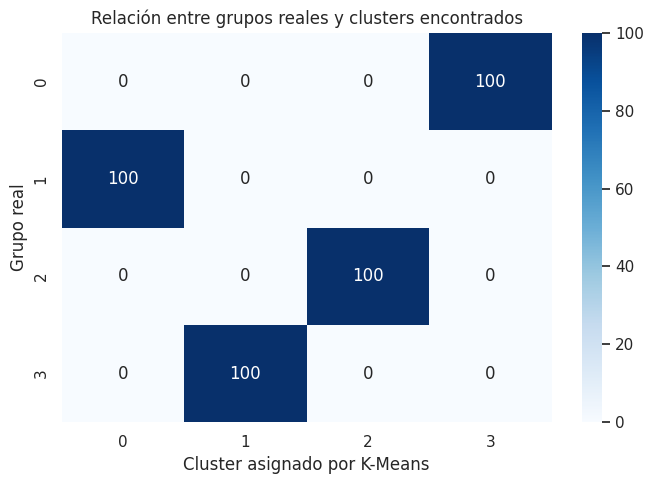

In [17]:
# ---------------------------------------------------------
# Tabla cruzada entre grupos reales y clusters encontrados
# ---------------------------------------------------------

tabla_grupo_cluster = pd.crosstab(
    df_k4["grupo_real"],
    df_k4["cluster_k4"]
)

display(tabla_grupo_cluster)

# ---------------------------------------------------------
# Mapa de calor para visualizar la relación
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    tabla_grupo_cluster,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Relación entre grupos reales y clusters encontrados")
plt.xlabel("Cluster asignado por K-Means")
plt.ylabel("Grupo real")
plt.tight_layout()
plt.show()

## 16. ¿Qué pasa si no sabemos cuántos clusters hay?

En este ejemplo comenzamos usando `k = 4` porque visualmente observamos cuatro grupos.

Pero en un problema real de clustering, muchas veces no sabemos de antemano cuántos grupos existen.

Esta es una diferencia muy importante respecto del aprendizaje supervisado. En clasificación, las clases suelen estar definidas en el dataset. En clustering, en cambio, debemos proponer una cantidad de grupos y analizar si esa decisión tiene sentido.

Por eso, elegir `k` no debe hacerse de manera automática. Es parte del análisis.

Una estrategia habitual consiste en probar varios valores de `k`, comparar los resultados y tomar una decisión combinando:

- métricas internas;
- visualizaciones;
- conocimiento del problema;
- utilidad práctica de los grupos encontrados.

A continuación vamos a entrenar varios modelos K-Means usando distintos valores de `k`.

## 17. Probamos distintos valores de k

Vamos a entrenar varios modelos K-Means, usando valores de `k` entre 2 y 8.

Para cada valor vamos a guardar dos medidas:

- **inercia**: mide qué tan compactos son los clusters;
- **silhouette score**: mide qué tan bien separado está cada punto respecto de otros clusters.

La inercia tiende a bajar cuando aumentamos `k`, porque al tener más clusters los puntos suelen quedar más cerca de algún centroide. Por eso no conviene usarla sola.

El silhouette score, en cambio, permite evaluar si los puntos están bien ubicados dentro de sus clusters. Sus valores van de -1 a 1:

- valores cercanos a 1 indican clusters bien definidos;
- valores cercanos a 0 indican puntos en zonas de frontera;
- valores negativos pueden indicar asignaciones poco adecuadas.

Estas métricas no reemplazan la interpretación, pero ayudan a comparar distintas soluciones.

In [18]:
# ---------------------------------------------------------
# Probamos distintos valores de k
# ---------------------------------------------------------

valores_k = range(2, 9)

resultados_k = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_escalado_df)

    etiquetas = modelo.labels_

    inercia = modelo.inertia_
    silueta = silhouette_score(X_escalado_df, etiquetas)

    resultados_k.append({
        "k": k,
        "inercia": inercia,
        "silhouette_score": silueta
    })

# ---------------------------------------------------------
# Convertimos los resultados en un DataFrame
# ---------------------------------------------------------

resultados_k_df = pd.DataFrame(resultados_k)

display(resultados_k_df)

,k,inercia,silhouette_score
0,2,420.649269,0.558606
1,3,96.008707,0.744279
2,4,22.641587,0.801903
3,5,20.283296,0.671910
4,6,17.983121,0.552455
5,7,15.809745,0.446076
6,8,14.021030,0.335127


## 18. Visualizamos la inercia y el silhouette score

La tabla anterior nos permite comparar distintos valores de `k`, pero los gráficos suelen hacer más clara la interpretación.

Vamos a construir dos visualizaciones:

1. Un gráfico de **inercia** para aplicar el método del codo.
2. Un gráfico de **silhouette score** para comparar la calidad de separación de los clusters.

En el gráfico de inercia buscaremos el punto donde la mejora empieza a estabilizarse.  
En el gráfico de silhouette score buscaremos valores altos, ya que indican clusters más compactos y mejor separados.

La elección de `k` no debe depender de una sola métrica. Lo ideal es combinar métricas, visualización e interpretación del problema.

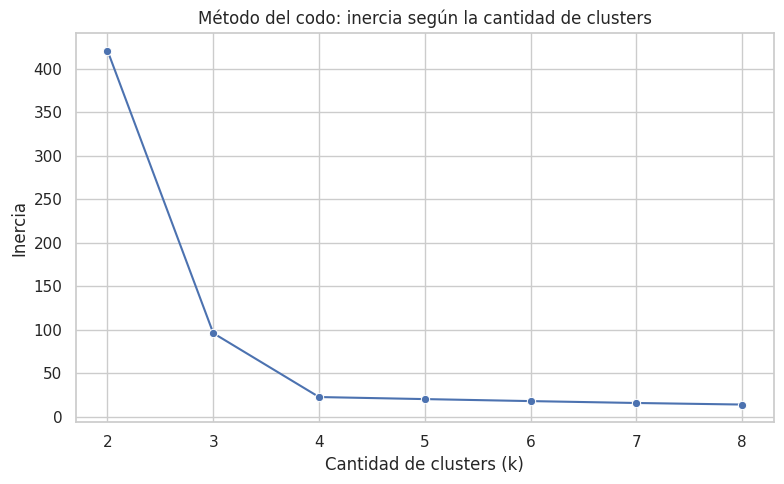

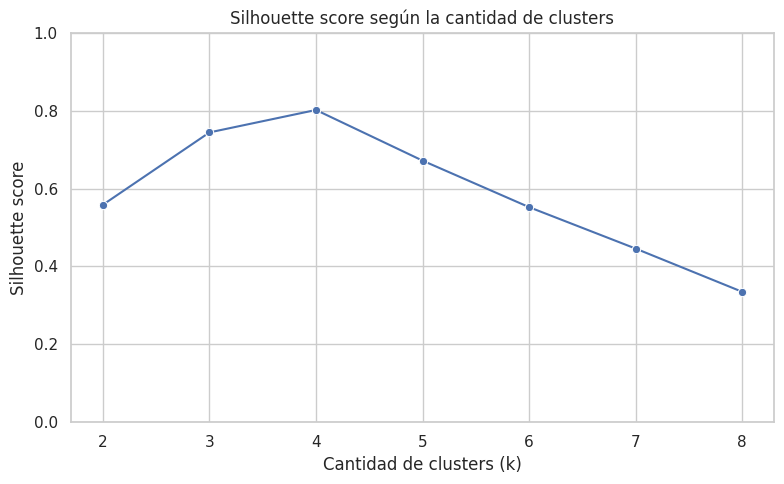

In [19]:
# ---------------------------------------------------------
# Gráfico del método del codo usando la inercia
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=resultados_k_df,
    x="k",
    y="inercia",
    marker="o"
)

plt.title("Método del codo: inercia según la cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(resultados_k_df["k"])
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Gráfico del silhouette score
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=resultados_k_df,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("Silhouette score según la cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(resultados_k_df["k"])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 19. Interpretamos la elección de k

Los resultados muestran que `k = 4` es una elección razonable para este dataset.

En el gráfico de inercia, el valor de `k = 4` aparece cerca del punto donde la curva empieza a estabilizarse. A este punto se lo suele llamar **codo**, porque marca el momento en que seguir aumentando la cantidad de clusters produce mejoras cada vez más pequeñas.

Además, el gráfico de silhouette score también favorece a `k = 4`, ya que allí se alcanza el valor más alto.

Esto refuerza una idea importante:

> Elegir `k` no significa encontrar una respuesta absoluta, sino construir una decisión razonable a partir de métricas, visualizaciones y conocimiento del problema.

En este caso, como los datos fueron generados con cuatro grupos compactos y bien separados, tanto la inercia como el silhouette score ayudan a identificar correctamente esa estructura.

## 20. ¿Qué pasa si elegimos mal el valor de k?

Para entender mejor la importancia de elegir `k`, vamos a comparar visualmente distintos valores.

Entrenaremos K-Means con:

- `k = 2`
- `k = 3`
- `k = 4`
- `k = 5`

Esto nos permitirá observar cómo cambia la segmentación.

Si usamos muy pocos clusters, el algoritmo se ve obligado a unir grupos que visualmente parecen distintos.  
Si usamos demasiados clusters, puede terminar dividiendo artificialmente grupos que deberían permanecer juntos.

El objetivo no es solamente encontrar un número, sino interpretar si la segmentación resultante tiene sentido.

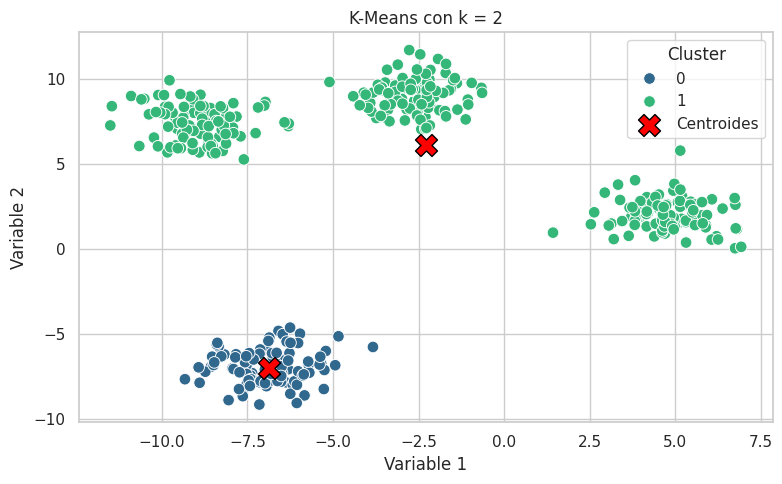

/n


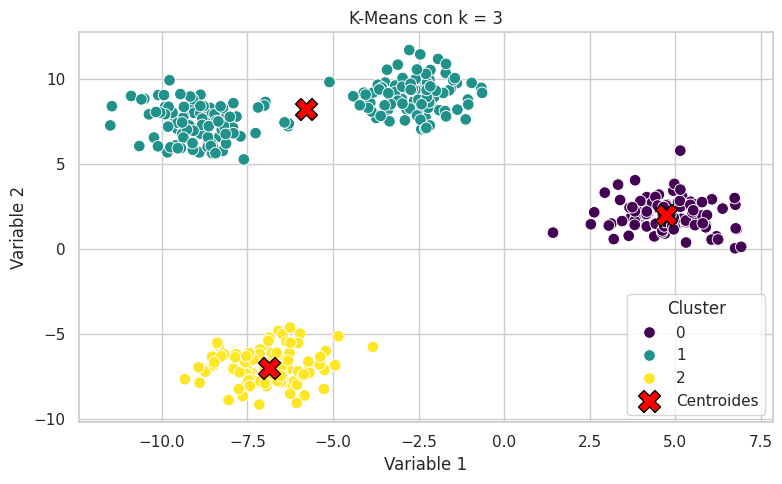

/n


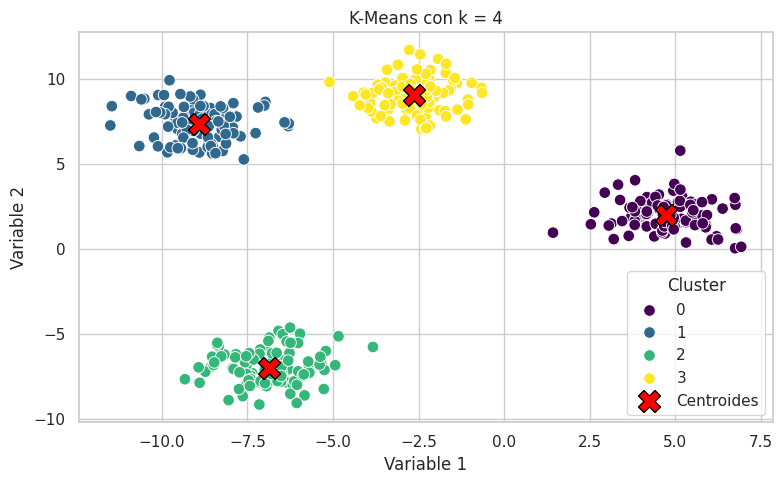

/n


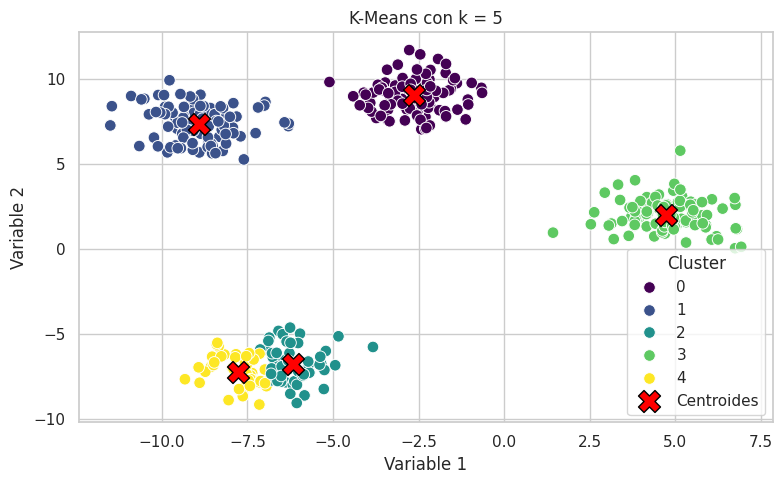

/n


In [21]:
# ---------------------------------------------------------
# Función auxiliar para entrenar K-Means y graficar resultados
# ---------------------------------------------------------

def graficar_kmeans_para_k(k):
    """
    Entrena K-Means con un valor dado de k y grafica
    los clusters encontrados junto con sus centroides.
    """

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_escalado_df)

    etiquetas = modelo.labels_

    # Convertimos los centroides a la escala original
    centroides_originales = escalador.inverse_transform(modelo.cluster_centers_)

    centroides_temp = pd.DataFrame(
        centroides_originales,
        columns=["variable_1", "variable_2"]
    )

    df_temp = df.copy()
    df_temp["cluster"] = etiquetas

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df_temp,
        x="variable_1",
        y="variable_2",
        hue="cluster",
        palette="viridis",
        s=70
    )

    plt.scatter(
        centroides_temp["variable_1"],
        centroides_temp["variable_2"],
        marker="X",
        s=250,
        c="red",
        edgecolor="black",
        label="Centroides"
    )

    plt.title(f"K-Means con k = {k}")
    plt.xlabel("Variable 1")
    plt.ylabel("Variable 2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    print("/n")

# ---------------------------------------------------------
# Graficamos distintos valores de k
# ---------------------------------------------------------

for k in [2, 3, 4, 5]:
    graficar_kmeans_para_k(k)

## 21. Interpretamos los distintos valores de k

Los gráficos anteriores muestran cómo cambia el resultado de K-Means cuando modificamos la cantidad de clusters.

Con `k = 2`, el algoritmo está obligado a formar solo dos grupos. Como los datos tienen una estructura visual más rica, algunos grupos que parecen separados terminan unidos dentro del mismo cluster.

Con `k = 3`, la segmentación mejora, pero todavía hay una agrupación que combina puntos que visualmente parecen pertenecer a grupos distintos.

Con `k = 4`, el resultado es mucho más coherente: cada cluster coincide con uno de los grupos visibles en el gráfico. Los centroides quedan ubicados en el centro aproximado de cada nube de puntos.

Con `k = 5`, el algoritmo empieza a dividir artificialmente uno de los grupos. Esto muestra que aumentar la cantidad de clusters no siempre produce una segmentación más útil. A veces solo fragmenta grupos que ya estaban bien definidos.

Este análisis refuerza una idea central:

> Elegir `k` implica buscar un equilibrio entre simplicidad y detalle.

Un valor demasiado bajo puede ocultar diferencias importantes.  
Un valor demasiado alto puede crear divisiones innecesarias.

## 22. Analizamos el silhouette score con más detalle

Hasta ahora usamos el silhouette score como un valor promedio para comparar distintos valores de `k`.

Sin embargo, también podemos analizar el silhouette score de cada punto.

Esto nos permite observar si todos los puntos están bien ubicados dentro de sus clusters o si algunos quedaron cerca de la frontera entre grupos.

Recordemos que el silhouette score puede tomar valores entre -1 y 1:

- valores cercanos a 1 indican que el punto está bien asignado a su cluster;
- valores cercanos a 0 indican que el punto está cerca de la frontera entre clusters;
- valores negativos sugieren que el punto podría estar mejor ubicado en otro cluster.

Como `k = 4` fue el valor más razonable según los análisis anteriores, vamos a calcular el silhouette score individual para ese caso.

,count,mean,min,max
cluster_k4,,,,
0,100,0.832220,0.554055,0.883282
1,100,0.745237,0.300495,0.827532
2,100,0.865571,0.689676,0.906220
3,100,0.764586,0.387749,0.832797


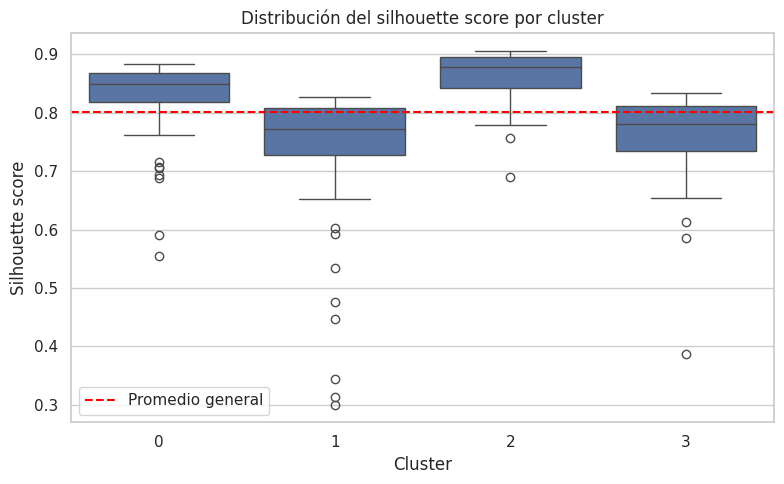

In [22]:
# ---------------------------------------------------------
# Calculamos el silhouette score individual para k = 4
# ---------------------------------------------------------

valores_silueta = silhouette_samples(
    X_escalado_df,
    clusters_k4
)

# ---------------------------------------------------------
# Agregamos los valores al DataFrame
# ---------------------------------------------------------

df_k4["silhouette"] = valores_silueta

# ---------------------------------------------------------
# Resumen del silhouette por cluster
# ---------------------------------------------------------

resumen_silueta = df_k4.groupby("cluster_k4")["silhouette"].agg(
    ["count", "mean", "min", "max"]
)

display(resumen_silueta)

# ---------------------------------------------------------
# Gráfico de distribución del silhouette por cluster
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_k4,
    x="cluster_k4",
    y="silhouette"
)

plt.axhline(
    silhouette_score(X_escalado_df, clusters_k4),
    linestyle="--",
    color="red",
    label="Promedio general"
)

plt.title("Distribución del silhouette score por cluster")
plt.xlabel("Cluster")
plt.ylabel("Silhouette score")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Interpretamos el silhouette score por cluster

El análisis del silhouette score muestra que los clusters encontrados con `k = 4` están bien definidos.

Todos los clusters tienen un promedio alto, lo que indica que, en general, los puntos están más cerca de los elementos de su propio cluster que de los puntos de otros clusters.

También podemos observar que algunos clusters tienen valores mínimos más bajos. Esto significa que algunos puntos están más cerca de las fronteras entre grupos. Sin embargo, como los promedios son altos y no aparecen valores negativos, no hay señales fuertes de una mala asignación.

Este resultado refuerza la elección de `k = 4`.

En este caso, las métricas, los gráficos y la estructura visual de los datos apuntan en la misma dirección: cuatro clusters es una elección razonable.

## 24. Comparamos grupos reales y clusters encontrados

Como este dataset fue generado artificialmente, tenemos una ventaja didáctica: conocemos el grupo real desde el cual fue generado cada punto.

En un problema real de clustering, normalmente no tendríamos esta información. Pero en este ejemplo podemos usarla para verificar visualmente si K-Means recuperó correctamente la estructura original.

Vamos a mostrar dos gráficos lado a lado:

- a la izquierda, los puntos coloreados según el grupo real;
- a la derecha, los puntos coloreados según el cluster encontrado por K-Means.

Es posible que los colores o los números no coincidan exactamente, porque las etiquetas de K-Means son arbitrarias. Lo importante es observar si la forma de los grupos coincide.

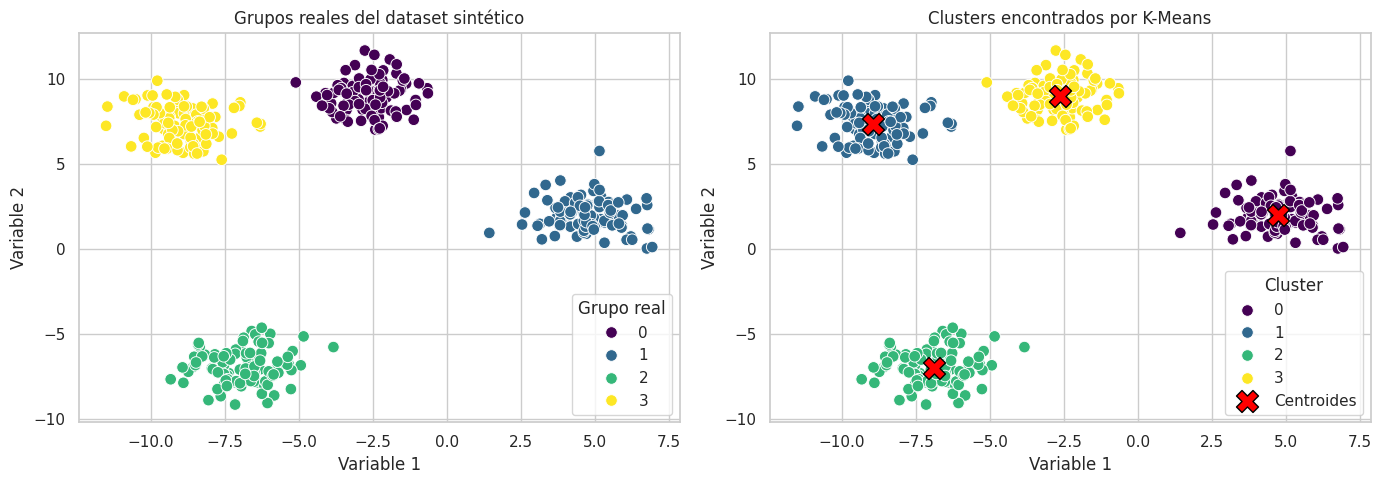

In [23]:
# ---------------------------------------------------------
# Comparación visual entre grupos reales y clusters encontrados
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico con grupos reales
sns.scatterplot(
    data=df_k4,
    x="variable_1",
    y="variable_2",
    hue="grupo_real",
    palette="viridis",
    s=70,
    ax=axes[0]
)

axes[0].set_title("Grupos reales del dataset sintético")
axes[0].set_xlabel("Variable 1")
axes[0].set_ylabel("Variable 2")
axes[0].legend(title="Grupo real")

# Gráfico con clusters encontrados
sns.scatterplot(
    data=df_k4,
    x="variable_1",
    y="variable_2",
    hue="cluster_k4",
    palette="viridis",
    s=70,
    ax=axes[1]
)

axes[1].scatter(
    centroides_df["variable_1"],
    centroides_df["variable_2"],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    label="Centroides"
)

axes[1].set_title("Clusters encontrados por K-Means")
axes[1].set_xlabel("Variable 1")
axes[1].set_ylabel("Variable 2")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

## 25. ¿Por qué K-Means funcionó tan bien en este ejemplo?

En este cuaderno, K-Means funcionó muy bien porque trabajamos con un dataset sintético generado en condiciones favorables.

Los grupos tenían varias características que ayudan al algoritmo:

- estaban bastante separados entre sí;
- eran compactos;
- tenían formas aproximadamente circulares;
- tenían tamaños similares;
- no había valores atípicos importantes;
- las variables fueron escaladas antes de entrenar el modelo.

Estas condiciones coinciden bastante bien con lo que K-Means necesita para obtener buenos resultados.

Sin embargo, en datasets reales no siempre ocurre esto. Los grupos pueden estar solapados, tener formas alargadas, tamaños muy distintos, densidades diferentes o valores extremos que afecten la posición de los centroides.

Por eso, este cuaderno debe entenderse como un primer caso ideal para comprender el algoritmo. No significa que K-Means vaya a funcionar igual de bien en cualquier conjunto de datos.

## 26. ¿Por qué K-Means puede fallar?

Aunque K-Means es simple, rápido y muy útil, tiene algunas limitaciones importantes.

La primera es que necesita que indiquemos de antemano la cantidad de clusters `k`. En algunos problemas esto puede ser difícil, porque no siempre sabemos cuántos grupos existen en los datos.

Otra limitación es que K-Means se basa en distancias respecto de centroides. Por eso funciona especialmente bien cuando los grupos son compactos y aproximadamente circulares. Si los clusters tienen formas irregulares, alargadas o muy solapadas, el algoritmo puede producir agrupamientos poco representativos.

También es sensible a la escala de las variables. Si no escalamos los datos, una variable con valores más grandes puede dominar el cálculo de distancias.

Además, los valores atípicos pueden afectar los centroides, ya que estos se calculan como promedios de los puntos asignados a cada cluster.

Por estas razones, aplicar K-Means no consiste solamente en ejecutar el algoritmo. También debemos observar los datos, probar distintos valores de `k`, analizar métricas, interpretar los gráficos y preguntarnos si los clusters encontrados tienen sentido.

## 27. Algunas alternativas a K-Means

K-Means no es el único algoritmo de clustering.

Existen otras alternativas que pueden ser más adecuadas según la forma y la estructura de los datos.

Por ejemplo, **DBSCAN** agrupa puntos según zonas de alta densidad. Puede detectar clusters con formas irregulares y también identificar puntos como ruido. Una ventaja importante es que no requiere definir previamente la cantidad de clusters.

Otra alternativa son los **modelos de mezcla gaussiana** o **GMM**. Estos modelos permiten trabajar con pertenencias probabilísticas, es decir, pueden estimar qué probabilidad tiene un punto de pertenecer a cada grupo.

También existe el **clustering jerárquico**, que construye agrupamientos progresivos y permite analizar los datos en distintos niveles de detalle.

No hay un algoritmo universalmente mejor. La elección depende del tipo de datos, del objetivo del análisis y de la interpretación que necesitemos construir.

# Reflexión final

En este cuaderno introdujimos el clustering usando K-Means sobre un dataset sintético.

Trabajamos con datos generados artificialmente para poder observar con claridad cómo funciona el algoritmo en condiciones favorables.

Durante el recorrido vimos que K-Means puede agrupar datos sin usar etiquetas previas. Para eso, calcula distancias entre puntos, asigna cada observación al centroide más cercano y actualiza esos centroides de manera iterativa hasta estabilizar los clusters.

También analizamos una de las decisiones más importantes del proceso: elegir la cantidad de clusters `k`.

Para eso probamos distintos valores y usamos dos herramientas complementarias:

- la **inercia**, que nos permitió aplicar el método del codo;
- el **silhouette score**, que nos ayudó a evaluar la separación de los clusters.

En este ejemplo, ambas métricas y las visualizaciones coincidieron en que `k = 4` era una elección razonable.

Sin embargo, también vimos que este buen resultado se debe a que los datos tenían una estructura ideal para K-Means: grupos compactos, separados y de tamaño similar.

La idea central de este cuaderno es que K-Means puede ser una herramienta muy poderosa para explorar datos sin etiquetas, pero sus resultados siempre deben interpretarse con cuidado.

En el próximo cuaderno vamos a aplicar K-Means a un dataset real: Palmer Penguins. Allí veremos que el algoritmo puede encontrar parte de la estructura de los datos, pero que no siempre logra separar los grupos de la manera que esperamos.